---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 1"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 3. Метод вузлових потенціалів</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Метод вузлових потенціалів</li>
  <li>Алгоритм методу</li>
  <li>Приклад: складання рівнянь для схеми з чотирма вузлами</li>
  <li>Випадок з двома вузлами</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 3 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Метод вузлових потенціалів](#node-voltage)
    * [Алгоритм методу](#node-voltage-algorithm)
    * [Приклад: складання рівнянь для схеми з чотирма вузлами](#node-voltage-example)
    * [Випадок з двома вузлами](#node-voltage-two)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

## Метод вузлових потенціалів <a class="anchor" id="node-voltage"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати сутність методу вузлових потенціалів
> - Визначати власні та міжвузлові провідності
> - Складати матрицю провідностей та вектор струмів
> - Розв'язувати систему рівнянь методом Крамера або матричним методом
> - Знаходити струми у гілках через знайдені потенціали

</div>

### Алгоритм методу <a class="anchor" id="node-voltage-algorithm"></a>

1. Вибрати **базовий (нульовий) вузол** — вузол з найбільшою кількістю підключених гілок
2. Визначити **власні провідності** вузлів: $g_{ii} = \sum g_k$ (сума провідностей гілок, підключених до вузла $i$)
3. Визначити **міжвузлові провідності**: $g_{ij} = -g_k$ (від'ємна провідність гілки між вузлами $i$ та $j$)
4. Визначити **власні струми** вузлів: $J_i = \sum E_k \cdot g_k$ (з урахуванням знаків)
5. Скласти систему рівнянь у матричній формі: $[G][\varphi] = [J]$
6. Розв'язати систему: $[\varphi] = [G]^{-1}[J]$
7. Знайти струми у гілках через потенціали вузлів



---
### Приклад: складання рівнянь для схеми з чотирма вузлами <a class="anchor" id="node-voltage-example"></a>

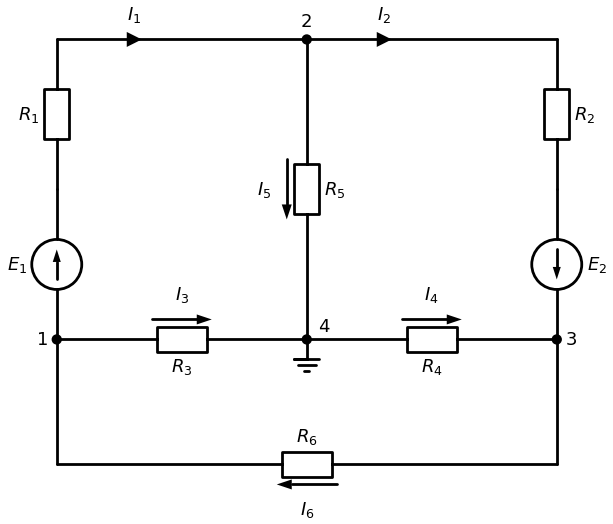

In [2]:
# Схема: коло з чотирма вузлами для методу вузлових потенціалів (вузол 4 — базовий, φ4 = 0)
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        n1, n4, n3 = (0, 0), (5, 0), (10, 0)
        # ліва гілка: E1, R1 (струм I1 від вузла 1 до вузла 2)
        d.add(EMF().at(n1).up().label('$E_1$'))
        d.add(elm.Resistor().up().label('$R_1$'))
        w1 = d.add(elm.Line().right(5))
        d.add(elm.CurrentLabelInline(direction='in').at(w1).label('$I_1$'))
        n2 = d.add(elm.Dot().label('2', loc='top'))
        # права гілка: R2, E2 (струм I2 від вузла 2 до вузла 3)
        w2 = d.add(elm.Line().right(5))
        d.add(elm.CurrentLabelInline(direction='in').at(w2).label('$I_2$'))
        d.add(elm.Resistor().down().label('$R_2$', loc='bottom'))
        d.add(EMF().down().label('$E_2$', loc='bottom'))
        # R5 між вузлами 2 і 4
        R5 = d.add(elm.Resistor().at(n2.center).down(6).label('$R_5$', loc='bottom'))
        d.add(elm.CurrentLabel(top=False, length=1.2).at(R5).label('$I_5$'))
        # R3 (1→4), R4 (4→3)
        R3 = d.add(elm.Resistor().at(n1).right(5).label('$R_3$', loc='bottom'))
        d.add(elm.CurrentLabel(top=True, length=1.2).at(R3).label('$I_3$'))
        R4 = d.add(elm.Resistor().at(n4).right(5).label('$R_4$', loc='bottom'))
        d.add(elm.CurrentLabel(top=True, length=1.2).at(R4).label('$I_4$'))
        # R6 (3→1) знизу
        d.add(elm.Line().at(n3).down(2.5))
        R6 = d.add(elm.Resistor().left(10).label('$R_6$', loc='top'))
        d.add(elm.CurrentLabel(top=True, length=1.2).at(R6).label('$I_6$'))
        d.add(elm.Line().up(2.5))
        d.add(elm.Dot().at(n1).label('1', loc='left'))
        d.add(elm.Dot().at(n3).label('3', loc='right'))
        d.add(elm.Dot().at(n4).label('4', loc='top', ofst=(0.35, 0)))
        d.add(elm.Ground().at(n4))

Запишемо рівняння потенціалів вузлів відносно нульового потенціалу вузла 4

$$ \varphi_2 = \varphi_1 + E_1 - I_1 \cdot R_1 $$
$$ \varphi_3 = \varphi_2 - I_2 \cdot R_2 + E_2 $$
$$ \varphi_1 = \varphi_3 - I_6 \cdot R_6 $$
$$ \varphi_1 = I_3 \cdot R_3 $$
$$ \varphi_2 = I_5 \cdot R_5 $$
$$ \varphi_3 = -I_4 \cdot R_4$$

Запишемо рівняння відносно струмів

$$ I_1 = (\varphi_1 - \varphi_2 + E_1) / R_1 $$

$$ I_2 = (\varphi_2 - \varphi_3 + E_2 )/R_2$$

$$ I_6 = (\varphi_3 -\varphi_1) / R_6 $$

$$ I_3 = \varphi_1 / R_3 $$

$$ I_5 = \varphi_2 / R_5 $$

$$ I_4 = -\varphi_3 / R_4$$

Запишемо рівняння з використанням провідностей

$$ I_1 = (\varphi_1 - \varphi_2 + E_1) \cdot g_1 $$

$$ I_2 = (\varphi_2 - \varphi_3 + E_2 ) \cdot g_2$$

$$ I_6 = (\varphi_3 -\varphi_1) \cdot g_6 $$

$$ I_3 = \varphi_1 \cdot g_3 $$

$$ I_5 = \varphi_2 \cdot g_5 $$

$$ I_4 = -\varphi_3 \cdot g_4$$

Запишемо рівняння для візлів схеми у відповідності до першого закону Кірхгофа

$$ I_6 - I_3 - I_1 = 0 $$

$$ I_1 - I_2 - I_5 = 0 $$

$$ I_2 + I_4 - I_6 = 0 $$

Підставляємо значення струмів

$$ (\varphi_3 -\varphi_1) \cdot g_6 - \varphi_1 \cdot g_3 - (\varphi_1 - \varphi_2 + E_1) \cdot g_1 = 0 $$

$$ (\varphi_1 - \varphi_2 + E_1) \cdot g_1 - (\varphi_2 - \varphi_3 + E_2 ) \cdot g_2 - \varphi_2 \cdot g_5 = 0 $$

$$ (\varphi_2 - \varphi_3 + E_2 ) \cdot g_2 -\varphi_3 \cdot g_4 - (\varphi_3 -\varphi_1) \cdot g_6 = 0 $$

Розкриваємо дужки

$$ \varphi_3\cdot g_6 -\varphi_1\cdot g_6 - \varphi_1 \cdot g_3 - \varphi_1 \cdot g_1 - \varphi_2 \cdot g_1 + E_1 \cdot g_1 = 0 $$

$$ \varphi_1\cdot g_1 - \varphi_2 \cdot g_1 + E_1 \cdot g_1 - \varphi_2\cdot g_2 - \varphi_3\cdot g_2 + E_2\cdot g_2 - \varphi_2 \cdot g_5 = 0 $$

$$ \varphi_2\cdot g_2 - \varphi_3\cdot g_2 + E_2\cdot g_2 -\varphi_3 \cdot g_4 - \varphi_3\cdot g_6 -\varphi_1\cdot g_6 = 0 $$

Перенесемо значення потенціалів вліво і згрупуємо

$$ \varphi_1 \cdot (g_3 + g_1 + g_6) - \varphi_2 \cdot g_1 - \varphi_3\cdot g_6 = - E_1 \cdot g_1 $$

$$ -\varphi_1\cdot g_1 - \varphi_2 \cdot ( g_1 + g_2 + g_5) - \varphi_3\cdot g_2 = E_1 \cdot g_1 - E_2\cdot g_2 $$

$$ -\varphi_1\cdot g_6 - \varphi_2\cdot g_2 + \varphi_3 \cdot (g_2 + g_4 + g_6) = E_2\cdot g_2 $$


> **Власна провідність вузла** визначається як сума провідностей всіх гілок дотичних до данного вузла

$$ g_{11} = g_{1} + g_{3} + g_{6} $$

$$ g_{22} = g_{1} + g_{5} + g_{2} $$

$$ g_{33} = g_{2} + g_{4} + g_{6} $$

> **Міжвузлова провідність** рівна провідності гілки, яка зв'язує два вказаних вузли. ЇЇ значення від'ємне

$$ g_{12} = g_{21} = -g_1 $$

$$ g_{23} = g_{32} = -g_2 $$

$$ g_{31} = g_{13} = -g_6 $$

> **Власний струм вузла** рівний алгебраїчній сумі добутку провідностей гілок на ЕРС гілок, дотичних до данного вузла

$$ J_1 = - E_1 \cdot g_1 $$

$$ J_2 = E_1 \cdot g_1 - E_2 \cdot g_2 $$

$$ J_3 = E_2 \cdot g_2 $$

Виконаємо заміни:

$$ \varphi_1 \cdot g_{11} + \varphi_2 \cdot g_{12} + \varphi_3\cdot g_{13} = J_1 $$

$$ \varphi_1 \cdot g_{21} - \varphi_2 \cdot g_{22} - \varphi_3\cdot g_{23} = J_2 $$

$$ \varphi_1 \cdot g_{31} + \varphi_2 \cdot g_{32} + \varphi_3\cdot g_{33} = J_3 $$

### Випадок з двома вузлами <a class="anchor" id="node-voltage-two"></a>

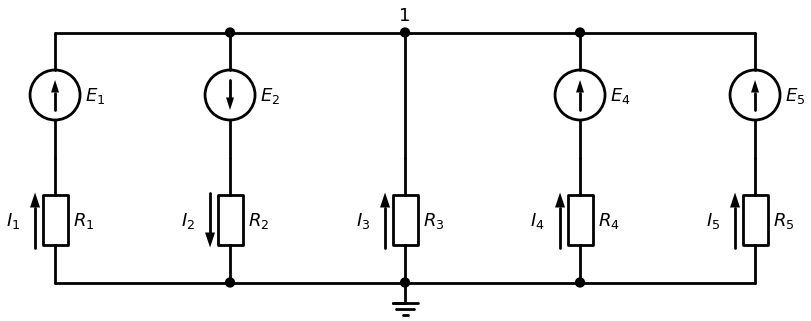

In [3]:
# Схема: коло з двома вузлами — п'ять паралельних гілок між вузлом 1 і базовим вузлом 0
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=2.5) as d:
        step = 3.5
        branches = [('E_1', 'up', 'R_1', 'I_1', True), ('E_2', 'down', 'R_2', 'I_2', False),
                    (None, None, 'R_3', 'I_3', True), ('E_4', 'up', 'R_4', 'I_4', True),
                    ('E_5', 'up', 'R_5', 'I_5', True)]
        for k, (e, edir, r, i, up) in enumerate(branches):
            x = k*step
            R = d.add(elm.Resistor().at((x, 0)).up().label(f'${r}$', loc='bottom'))
            d.add(elm.CurrentLabel(top=True, length=1.1, reverse=not up).at(R).label(f'${i}$'))
            if e:
                src = EMF().up() if edir == 'up' else EMF().up().reverse()
                d.add(src.label(f'${e}$', loc='bottom'))
            else:
                d.add(elm.Line().up())
        top = d.add(elm.Line().at((0, 5)).right(4*step))
        bot = d.add(elm.Line().at((0, 0)).right(4*step))
        d.add(elm.Dot().at((2*step, 5)).label('1', loc='top'))
        d.add(elm.Dot().at((2*step, 0)))
        d.add(elm.Ground().at((2*step, 0)))
        for k in (1, 3):
            d.add(elm.Dot().at((k*step, 5))); d.add(elm.Dot().at((k*step, 0)))

$$ \varphi_1 \cdot g_{11} = J_1 $$

Власна провідність вузла:

$$ g_{11} = g_1 + g_2 + g_3 + g_4 + g_5$$

Власний струм вузла:

$$ J_1 = E_1 \cdot g_1 - E_2 \cdot g_2 + E_4 \cdot g_4 + E_5 \cdot g_5 $$

Виконаємо підстановку:

$$ \varphi_1 \cdot (g_1 + g_2 + g_3 + g_4 + g_5) = E_1 \cdot g_1 - E_2 \cdot g_2 + E_4 \cdot g_4 + E_5 \cdot g_5 $$

Виразимо потенціал вузла:

$$ \varphi_1  = \cfrac{E_1 \cdot g_1 - E_2 \cdot g_2 + E_4 \cdot g_4 + E_5 \cdot g_5}
{g_1 + g_2 + g_3 + g_4 + g_5}$$

В загальному вигляді формула для розрахунку потенціала вузла має наступний вигляд:

$$ \varphi_1 = \cfrac{\sum_{k=1}^{n} E_{k}\cdot g_{k}}{\sum_{k=1}^{n} g_{k}} $$

Розрахуємо струми в гілках:

$$
\begin{cases} 
I_1 = (E_1 - \varphi_1) \cdot g_1 \\
I_2 = (E_2 + \varphi_1) \cdot g_2 \\
I_3 = (- \varphi_1) \cdot g_3 \\
I_4 = (E_4 - \varphi_1) \cdot g_4 \\
I_5 = (E_5 - \varphi_1) \cdot g_5 
\end{cases} 
$$

**Числовий приклад для двох вузлів.** Задамо $E_1 = 40$ В, $E_2 = 20$ В, $R_1 = R_3 = 10$ Ом, $R_2 = 40$ Ом і за допомогою SymPy знайдемо потенціал вузла $\varphi_1$ у символьному вигляді.

In [4]:
# Крок 1: параметри кола
E1_s = 40;
E2_s = 20;

R1_s = 10;
R2_s = 40;
R3_s = 10;

E1 = smp.symbols('E1')
E2 = smp.symbols('E2')
R1 = smp.symbols('R1')
R2 = smp.symbols('R2')
R3 = smp.symbols('R3')
Phi1 = smp.symbols('Phi1')

# Крок 2: система рівнянь
eq = Phi1 * (1/R1 +1/R2 + 1/R3) - E1*(1/R1) + E2*(1/R2)

# Крок 3: розв'язуємо систему рівнянь
sol = smp.solve(eq, Phi1)
sol


[R3*(E1*R2 - E2*R1)/(R1*R2 + R1*R3 + R2*R3)]

Перетворимо символьний вираз для $\varphi_1$ на звичайну функцію Python (`lambdify`), щоб швидко підставляти числа.

In [5]:
# Крок 4: перетворюємо символьний розв'язок на функцію Python
Phi_func = smp.lambdify([R1, R2,R3,E1,E2], sol, 'numpy')

Обчислимо потенціал вузла для заданих числових значень:

In [6]:
Phi_func(R1_s, R2_s, R3_s, E1_s, E2_s)

[15.555555555555555]

Побудуємо залежність потенціалу вузла $\varphi_1$ від ЕРС $E_2$ (решта параметрів незмінні). Залежність лінійна, як і має бути для лінійного кола.

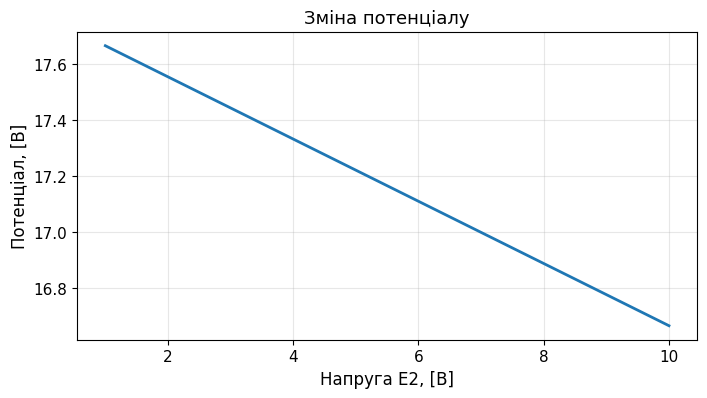

In [7]:
# Крок 5: діапазон значень E2
E2_values = np.linspace(1, 10, 10)  # значення E2, В

# Крок 6: потенціал вузла для кожного значення E2
potential_values = np.array([Phi_func(10, R2_s, R3_s, E1_s, E2_sub) for E2_sub in E2_values])

# Крок 7: графік
plt.plot(E2_values, potential_values)
plt.title('Зміна потенціалу')
plt.xlabel('Напруга Е2, [В]')
plt.ylabel('Потенціал, [В]')
plt.grid(True)
plt.show()

---

### 📌 Підсумок: Метод вузлових потенціалів

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Матрична форма системи рівнянь:**

$$[G] \cdot [\varphi] = [J]$$

де $[G]$ — матриця провідностей, $[\varphi]$ — вектор потенціалів вузлів, $[J]$ — вектор струмів

**Формула для двох вузлів:**

$$\varphi_1 = \cfrac{\sum_{k=1}^{n} E_k \cdot g_k}{\sum_{k=1}^{n} g_k}$$

**Переваги методу:**
- Мінімальна кількість рівнянь при малій кількості вузлів
- Ефективний для схем з паралельними гілками
- Систематичний підхід, зручний для комп'ютерного моделювання

</div>

---


In [8]:
# Інтерактивний метод вузлових потенціалів (2 вузли)
def node_voltage_interactive(E1=40, E2=20, R1=10, R2=40, R3=10):
    """Два незалежних вузли, три гілки"""
    # phi1 — потенціал єдиного незалежного вузла; базовий вузол — 2
    g1, g2, g3 = 1/R1, 1/R2, 1/R3
    phi1 = (E1*g1 - E2*g2) / (g1 + g2 + g3)
    I1 = (phi1 - E1) * g1   # струм через R1 (гілка з E1)
    I2 = (phi1 + E2) * g2   # струм через R2 (гілка з E2)
    I3 = phi1 * g3           # струм через R3

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # потенціал
    axes[0].bar(['phi_1 (В)'], [phi1], color='#2196F3', edgecolor='k')
    axes[0].set_title(f'Потенціал вузла: {phi1:.3f} В')
    axes[0].set_ylabel('Напруга, В')

    # струми
    colors = ['#4CAF50' if v >= 0 else '#F44336' for v in [I1, I2, I3]]
    axes[1].bar(['I1', 'I2', 'I3'], [I1, I2, I3], color=colors, edgecolor='k')
    axes[1].axhline(0, color='k', lw=0.8)
    axes[1].set_title('Струми в гілках (А)')
    axes[1].set_ylabel('Струм, А')

    # частки провідностей
    axes[2].pie([g1, g2, g3], labels=[f'g1={g1:.3f}', f'g2={g2:.3f}', f'g3={g3:.3f}'],
               autopct='%1.1f%%', startangle=90,
               colors=['#2196F3','#FF9800','#4CAF50'])
    axes[2].set_title('Частки провідностей')

    kcl_check = abs(I1 + I2 + I3)
    plt.suptitle(f'phi1 = {phi1:.4f} В | KCL: |sum(I)| = {kcl_check:.2e}',
                 fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'phi1 = {phi1:.4f} В')
    print(f'I1 = {I1:.4f} А | I2 = {I2:.4f} А | I3 = {I3:.4f} А')
    print(f'KCL check sum = {I1+I2+I3:.2e}')

interact(node_voltage_interactive,
         E1=widgets.FloatSlider(min=0, max=100, step=1, value=40, description='E1 (В)'),
         E2=widgets.FloatSlider(min=0, max=100, step=1, value=20, description='E2 (В)'),
         R1=widgets.FloatSlider(min=1, max=200, step=5, value=10, description='R1 (Ом)'),
         R2=widgets.FloatSlider(min=1, max=200, step=5, value=40, description='R2 (Ом)'),
         R3=widgets.FloatSlider(min=1, max=200, step=5, value=10, description='R3 (Ом)'))

interactive(children=(FloatSlider(value=40.0, description='E1 (В)', step=1.0), FloatSlider(value=20.0, descrip…

<function __main__.node_voltage_interactive(E1=40, E2=20, R1=10, R2=40, R3=10)>

---
### ⚡ Практичне застосування: Метод вузлових потенціалів

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Метод вузлових потенціалів у SPICE-симуляторах:**

Всі сучасні SPICE-симулятори (LTspice, NgSpice, Cadence Spectre) в основі використовують саме метод вузлових потенціалів, відомий як **Modified Nodal Analysis (MNA)**.

Формування матриці MNA:
$$[G + sC] \cdot [v] = [i]$$
де:
- $G$ — матриця провідностей
- $C$ — матриця ємностей (для AC/Transient)
- $v$ — вектор вузлових напруг (шуканих)
- $i$ — вектор збуджувальних струмів

**Реальне застосування:**

| Задача | Кількість вузлів | Метод |
|--------|----------------|---------|
| Транзисторний каскад (BJT) | 3–5 вузлів | MNA вручну / SPICE |
| Операційний підсилювач | 5–10 вузлів | SPICE |
| Мікросхема (IC) | $10^6$+ вузлів | Ітераційний MNA |

> Метод ефективний, коли **кількість вузлів** менша за кількість гілок.

</div>

---
### ✅ Питання для самоперевірки: Метод вузлових потенціалів

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Що таке власна провідність вузла?</summary>

> **Відповідь:** $g_{ii}$ — сума провідностей усіх гілок, що з'єднують $i$-й вузол з іншими вузлами (без урахування знаку). Це діагональний елемент матриці провідностей.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Коли метод двох вузлів можна застосувати і яка його формула?</summary>

> **Відповідь:** Коли в схемі є лише один незалежний вузол (два вузли, один із яких — «земля»). Формула:
> $$\varphi_1 = \frac{\sum_{k} E_k g_k}{\sum_{k} g_k}$$
> де підсумовування — по всіх провідних гілках, $E_k$ береться зі знаком «+», якщо ЕРС підвищує потенціал до вузла $\varphi_1$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як увести джерело струму в рівняння вузлових потенціалів?</summary>

> **Відповідь:** Джерело струму $J_k$ у гілці, що з'єднує вузол $i$ із землею, додається безпосередньо до вектора правих частин: $J_i \mathrel{+}= J_k$ (зі знаком «+», якщо струм спрямований у вузол).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4 (поглиблений).</b> Як пов'язані MNA та метод вузлових потенціалів у SPICE?</summary>

> **Відповідь:** MNA розширює класичний метод вузлових потенціалів, додаючи рівняння для гілок із джерелами напруги та індуктивностями. Це дає матрицю, яка може розв'язуватись ітераційно (метод Ньютона—Рафсона для нелінійних схем).

</details>

---
### 📝 Задачі для самостійного розв'язання: Метод вузлових потенціалів


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Коло з двома вузлами: гілка 1 — $E_1 = 12$ В, $R_1 = 3$ Ом; гілка 2 — $E_2 = 6$ В, $R_2 = 6$ Ом; гілка 3 — лише $R_3 = 2$ Ом; крім того, у вузол втікає струм джерела струму $J = 1$ А. Обидві ЕРС напрямлені до вузла 1. Знайдіть потенціал вузла і струми гілок.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\varphi_1 = \dfrac{E_1g_1 + E_2g_2 + J}{g_1 + g_2 + g_3} = \dfrac{4 + 1 + 1}{1/3 + 1/6 + 1/2} = 6$ В.
> $I_1 = (12-6)/3 = 2$ А, $I_2 = (6-6)/6 = 0$, $I_3 = 6/2 = 3$ А. Перевірка: $2 + 0 + 1 = 3$ ✔.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Складіть матрицю провідностей і знайдіть потенціали для кола: між базисним вузлом 0 і вузлом 1 — гілка $E_1 = 10$ В, $R_1 = 5$ Ом (ЕРС до вузла 1) та паралельно $R_2 = 10$ Ом; між вузлами 1 і 2 — $R_3 = 5$ Ом; між вузлом 2 і вузлом 0 — $R_4 = 10$ Ом і джерело струму $J = 2$ А (струм у вузол 2).

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\begin{bmatrix}0{,}5 & -0{,}2\\ -0{,}2 & 0{,}3\end{bmatrix}\begin{bmatrix}\varphi_1\\ \varphi_2\end{bmatrix} = \begin{bmatrix}2\\ 2\end{bmatrix}$ (См, А).
> $\varphi_1 = 1/0{,}11 \approx 9{,}09$ В, $\varphi_2 = 1{,}4/0{,}11 \approx 12{,}73$ В. Струм через $R_3$ тече від вузла 2 до вузла 1: $(12{,}73 - 9{,}09)/5 \approx 0{,}73$ А.

</details>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 2. Закони Кірхгофа](Тема_02_Закони_Кірхгофа.ipynb) &nbsp;|&nbsp; [Тема 4. Метод контурних струмів](Тема_04_Метод_контурних_струмів.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
